In [4]:
# Import an meaningful csv file for data analysis and perform data cleaning, and analysis for meaningful output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the dataset
df = pd.read_csv('tips.csv')
# Display the first few rows of the dataset
print(df.head())
# Check for missing values
print(df.isnull().sum())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [14]:
# Perform data cleaning if necessary (e.g., handle missing values, remove duplicates)
# For this dataset, there are no missing values, so we can proceed with analysis
# Basic statistics of the dataset
print(df.describe())
print("\n\n")
# Group by 'day' and calculate the total bill and tip
res = df.groupby('day').agg({'total_bill':'sum', 'tip':'sum'})
print(res)

       total_bill         tip        size
count  243.000000  243.000000  243.000000
mean    19.813868    3.002387    2.572016
std      8.910071    1.385002    0.952356
min      3.070000    1.000000    1.000000
25%     13.380000    2.000000    2.000000
50%     17.810000    2.920000    2.000000
75%     24.175000    3.575000    3.000000
max     50.810000   10.000000    6.000000



      total_bill     tip
day                     
Fri       325.88   51.96
Sat      1778.40  260.40
Sun      1627.16  247.39
Thur     1083.33  169.83


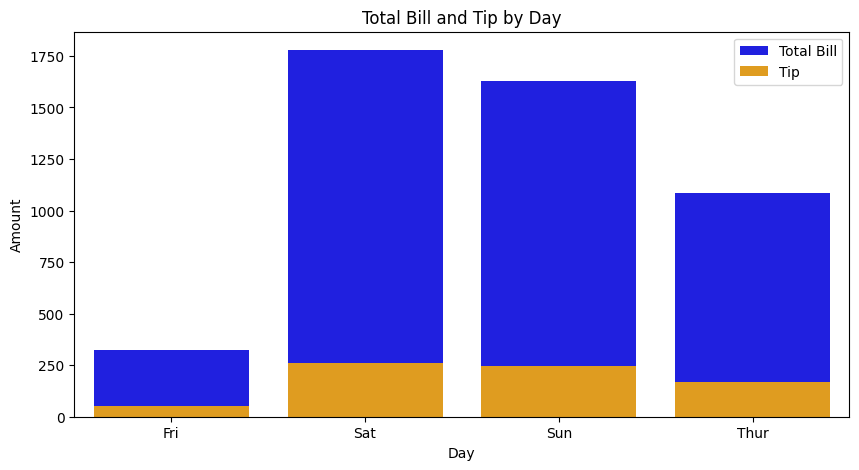

In [13]:
# visualize the total bill and tip by day
plt.figure(figsize=(10, 5))
sns.barplot(x=res.index, y=res['total_bill'], color='blue', label='Total Bill')
sns.barplot(x=res.index, y=res['tip'], color='orange', label='Tip')
plt.title('Total Bill and Tip by Day')
plt.xlabel('Day')
plt.ylabel('Amount')
plt.legend()
plt.show()

In [15]:
# calculate the average tip percentage by day
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100
avg_tip_percentage = df.groupby('day')['tip_percentage'].mean()
print(avg_tip_percentage)

day
Fri     16.991303
Sat     15.315172
Sun     16.689729
Thur    16.139743
Name: tip_percentage, dtype: float64


In [19]:
# remove duplicates if any
df = df.drop_duplicates()
print("Number of duplicates removed:", df.duplicated().sum())

Number of duplicates removed: 0


In [20]:
# more analysis 
day_time_group = df.groupby(['day', 'time']).agg({'total_bill':'mean', 'tip':'mean'})
print(day_time_group)

             total_bill       tip
day  time                        
Fri  Dinner   19.663333  2.940000
     Lunch    12.845714  2.382857
Sat  Dinner   20.441379  2.993103
Sun  Dinner   21.410000  3.255132
Thur Dinner   18.780000  3.000000
     Lunch    17.742500  2.780500
